# WTI COT MM Nowcasting — Kalman Filter — 01 EDA

State-space oriented exploratory analysis for the multivariate Kalman filter pipeline.

**Responses modelled jointly:** MM Net, Long, Short position changes (and their OI-scaled variants)  
**Goal:** Characterise the time-series properties of the responses and select a compact feature subset (~5) to use as exogenous inputs.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append('../../../')

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

In [4]:
from src.utils.io.read import PreprocessedDataReader
from src.preprocessing.base import FutureTicker
from src.settings import Settings

pdr = PreprocessedDataReader(Settings.historical.paths.PREPROCESSED_DATA_PATH)
dataset = pdr.read_dataset(ticker=FutureTicker.WTI)
dataset['tradeDate'] = pd.to_datetime(dataset['tradeDate'])
dataset.sort_values('tradeDate', inplace=True)
dataset.reset_index(drop=True, inplace=True)

print(f'Shape: {dataset.shape}')
print(f'Date range: {dataset["tradeDate"].min().date()} → {dataset["tradeDate"].max().date()}')
dataset.tail(3)

Shape: (813, 81)
Date range: 2010-01-05 → 2025-07-29


,tradeDate,Name,Commercial_NetPosition,CommercialLongPosition,CommercialShortPosition,ManagedMoney_NetPosition,ManagedMoney_LongPosition,ManagedMoney_ShortPosition,Commercial_NetPosition_change,prior_report_Commercial_NetPosition_change,...,prior_cumulative_5D_F2_Volume_change,next_prior_cumulative_5D_F2_Volume_change,prior_cumulative_5D_F1MinusF2_Volume_change,next_prior_cumulative_5D_F1MinusF2_Volume_change,F1_RolledPrice_change,next_F1_RolledPrice_change,F2_RolledPrice_change,next_F2_RolledPrice_change,F3_RolledPrice_change,next_F3_RolledPrice_change
810,2025-07-15,CL,368688.0,1226014.0,857326.0,217954.0,404769.0,186815.0,31871.0,25279.0,...,225987.0,335852.0,-232123.0,-916765.0,-1.81,0.08,-1.61,0.11,-1.33,0.18
811,2025-07-22,CL,355309.0,1179861.0,824552.0,208836.0,406472.0,197636.0,-13379.0,31871.0,...,335852.0,-652406.0,-916765.0,1366289.0,0.08,3.90,0.11,3.82,0.18,3.64
812,2025-07-29,CL,362436.0,1172427.0,809991.0,207342.0,411275.0,203933.0,7127.0,-13379.0,...,-652406.0,NaN,1366289.0,NaN,3.90,NaN,3.82,NaN,3.64,NaN


---
## 1. Response Variables

The three responses we will model **jointly** in the multivariate KF:

| Variable | Description |
|---|---|
| `prior_report_ManagedMoney_NetPosition_change` | Week-on-week net position change (contracts) |
| `prior_report_ManagedMoney_LongPosition_change` | Week-on-week long position change |
| `prior_report_ManagedMoney_ShortPosition_change` | Week-on-week short position change |

OI-scaled variants will be used in parallel.

In [5]:
# Raw responses (position changes)
RAW_RESPONSES = [
    'prior_report_ManagedMoney_NetPosition_change',
    'prior_report_ManagedMoney_LongPosition_change',
    'prior_report_ManagedMoney_ShortPosition_change',
]

# OI-scaled responses
OI_RESPONSES = [
    'prior_report_ManagedMoney_NetPosition_to_openinterest_change',
    'prior_report_ManagedMoney_LongPosition_to_openinterest_change',
    'prior_report_ManagedMoney_ShortPosition_to_openinterest_change',
]

ALL_RESPONSES = RAW_RESPONSES + OI_RESPONSES

print('Response columns present:', all(c in dataset.columns for c in ALL_RESPONSES))

Response columns present: True


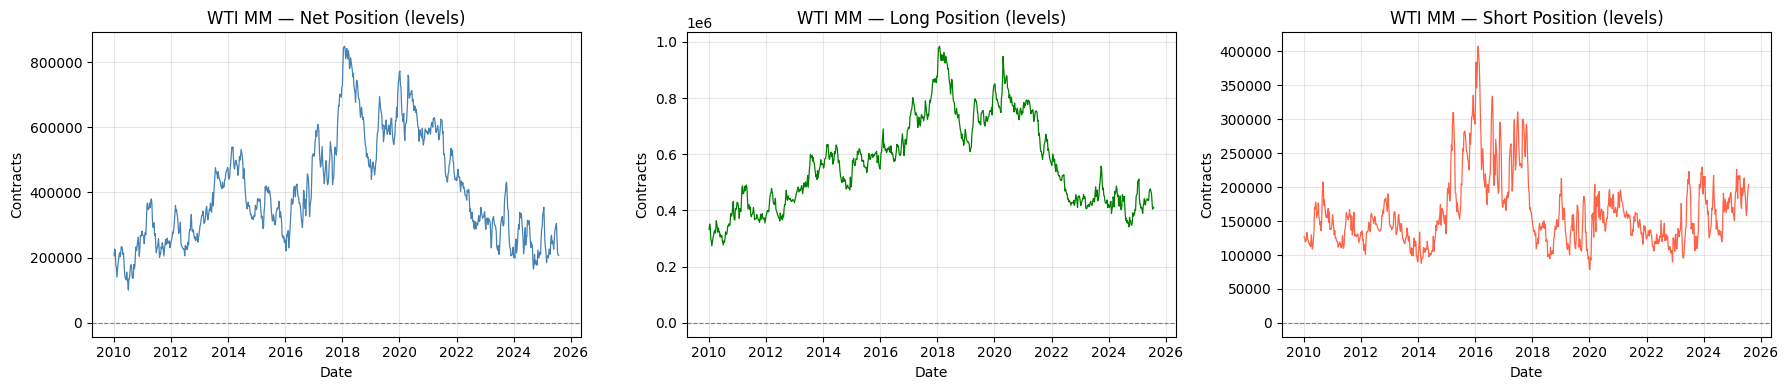

In [6]:
# --- Level plots (MM positions) ---
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
level_cols = [
    'ManagedMoney_NetPosition',
    'ManagedMoney_LongPosition',
    'ManagedMoney_ShortPosition',
]
titles = ['Net Position', 'Long Position', 'Short Position']
colors = ['steelblue', 'green', 'tomato']

for ax, col, title, color in zip(axes, level_cols, titles, colors):
    ax.plot(dataset['tradeDate'], dataset[col], color=color, linewidth=0.9)
    ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)
    ax.set_title(f'WTI MM — {title} (levels)')
    ax.set_xlabel('Date')
    ax.set_ylabel('Contracts')

plt.tight_layout()
plt.show()

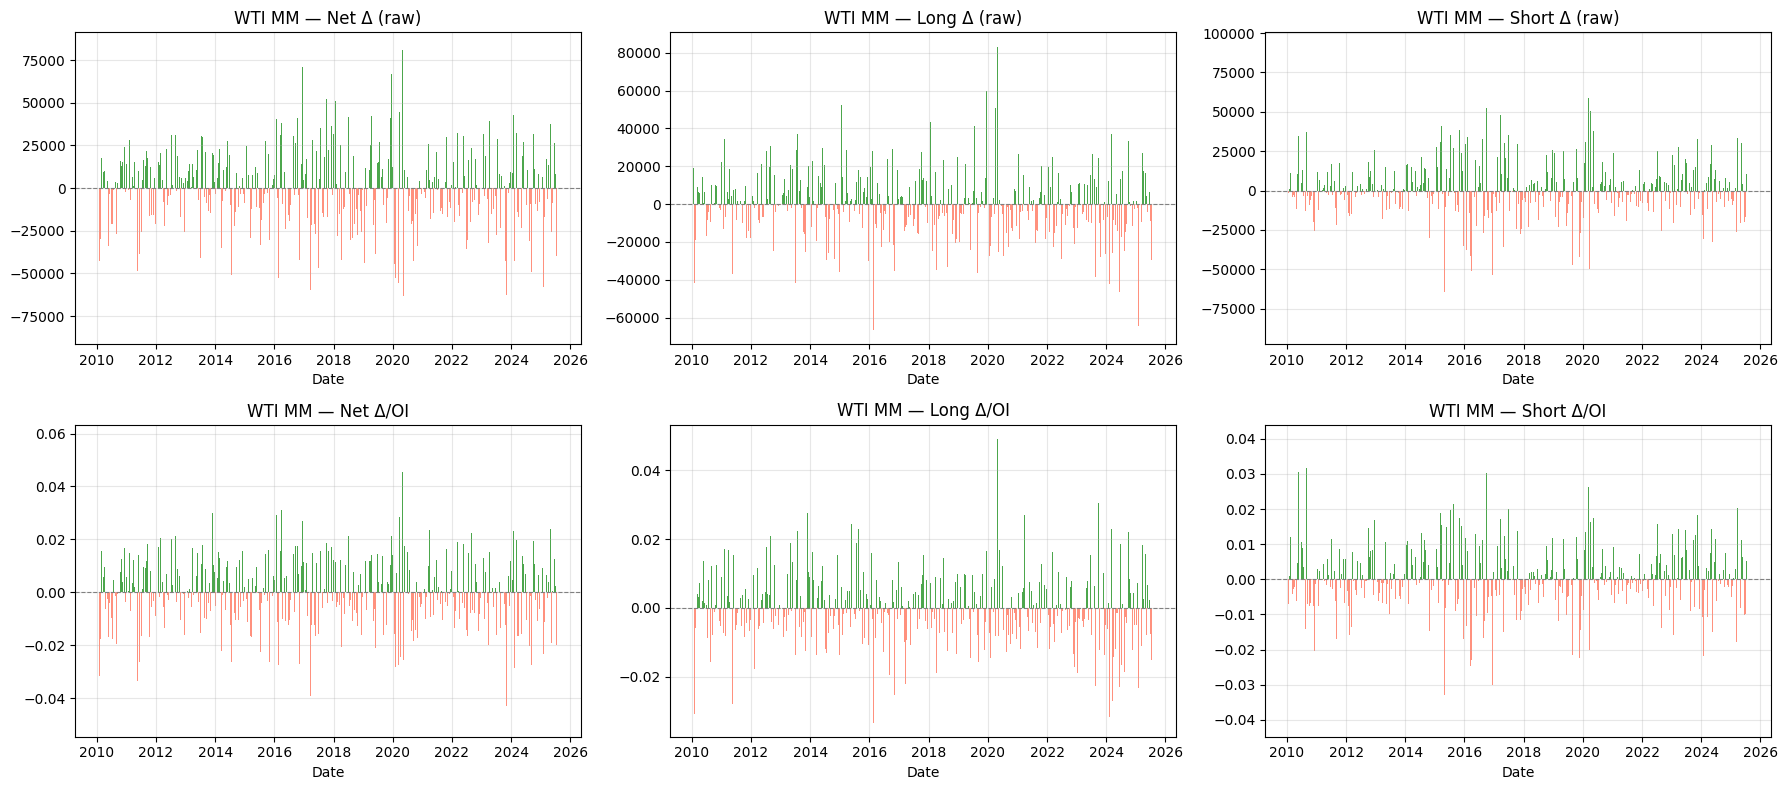

In [7]:
# --- Change plots (responses) ---
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
change_labels = ['Net Δ (raw)', 'Long Δ (raw)', 'Short Δ (raw)',
                 'Net Δ/OI', 'Long Δ/OI', 'Short Δ/OI']

for i, (ax, col, label) in enumerate(zip(axes.flatten(), ALL_RESPONSES, change_labels)):
    vals = dataset[col].dropna()
    ax.bar(dataset.loc[vals.index, 'tradeDate'], vals,
           color=['green' if v >= 0 else 'tomato' for v in vals],
           width=5, alpha=0.7)
    ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)
    ax.set_title(f'WTI MM — {label}')
    ax.set_xlabel('Date')

plt.tight_layout()
plt.show()

In [8]:
# --- Summary statistics ---
stats_df = dataset[ALL_RESPONSES].describe().T
stats_df['skew'] = dataset[ALL_RESPONSES].skew()
stats_df['kurt'] = dataset[ALL_RESPONSES].kurtosis()
stats_df.index = [
    'Net Δ (raw)', 'Long Δ (raw)', 'Short Δ (raw)',
    'Net Δ/OI', 'Long Δ/OI', 'Short Δ/OI',
]
stats_df[['count', 'mean', 'std', 'min', 'max', 'skew', 'kurt']].round(4)

,count,mean,std,min,max,skew,kurt
Net Δ (raw),811.0,3.6732,22858.2738,-83127.0000,82933.0000,0.0048,0.6477
Long Δ (raw),811.0,90.9162,18057.4184,-66539.0000,83266.0000,0.1904,1.1110
Short Δ (raw),811.0,87.2429,16489.3761,-88620.0000,91462.0000,0.1476,3.4527
Net Δ/OI,799.0,-0.0001,0.0131,-0.0492,0.0580,0.0064,0.7372
Long Δ/OI,799.0,-0.0001,0.0106,-0.0333,0.0491,0.2210,0.6999
Short Δ/OI,799.0,0.0000,0.0088,-0.0408,0.0399,0.1047,2.1372


---
## 2. Stationarity Tests

We test **levels** and **changes** separately to decide what the KF should model directly.

- **ADF** (null = unit root → non-stationary): reject → stationary  
- **KPSS** (null = stationary): reject → non-stationary  

Agreement between both tests gives confidence.

In [9]:
def run_stationarity_tests(series, name):
    s = series.dropna()
    adf_stat, adf_p, _, _, adf_crit, _ = adfuller(s, autolag='AIC')
    try:
        kpss_stat, kpss_p, _, kpss_crit = kpss(s, regression='c', nlags='auto')
    except Exception:
        kpss_stat, kpss_p = np.nan, np.nan

    adf_conclusion = 'Stationary' if adf_p < 0.05 else 'Non-stationary'
    kpss_conclusion = 'Non-stationary' if kpss_p < 0.05 else 'Stationary'

    return {
        'Series': name,
        'ADF stat': round(adf_stat, 4),
        'ADF p-val': round(adf_p, 4),
        'ADF conclusion': adf_conclusion,
        'KPSS stat': round(kpss_stat, 4),
        'KPSS p-val': round(kpss_p, 4),
        'KPSS conclusion': kpss_conclusion,
    }

In [10]:
# Test levels
level_results = []
for col, label in zip(level_cols, ['Net (level)', 'Long (level)', 'Short (level)']):
    level_results.append(run_stationarity_tests(dataset[col], label))

pd.DataFrame(level_results).set_index('Series')

/var/folders/hf/hwg72r856z362qcrv_4q2xp00000gn/T/ipykernel_30625/117813256.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, _, kpss_crit = kpss(s, regression='c', nlags='auto')
/var/folders/hf/hwg72r856z362qcrv_4q2xp00000gn/T/ipykernel_30625/117813256.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, _, kpss_crit = kpss(s, regression='c', nlags='auto')
/var/folders/hf/hwg72r856z362qcrv_4q2xp00000gn/T/ipykernel_30625/117813256.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, kpss_crit = kpss(s, regression='c', nlags='auto')


,ADF stat,ADF p-val,ADF conclusion,KPSS stat,KPSS p-val,KPSS conclusion
Series,,,,,,
Net (level),-2.3571,0.1542,Non-stationary,0.9731,0.01,Non-stationary
Long (level),-1.8421,0.3598,Non-stationary,1.1044,0.01,Non-stationary
Short (level),-4.0996,0.0010,Stationary,0.3315,0.10,Stationary


In [11]:
# Test changes (our model responses)
change_labels_short = [
    'Net Δ (raw)', 'Long Δ (raw)', 'Short Δ (raw)',
    'Net Δ/OI', 'Long Δ/OI', 'Short Δ/OI',
]
change_results = []
for col, label in zip(ALL_RESPONSES, change_labels_short):
    change_results.append(run_stationarity_tests(dataset[col], label))

pd.DataFrame(change_results).set_index('Series')

/var/folders/hf/hwg72r856z362qcrv_4q2xp00000gn/T/ipykernel_30625/117813256.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, kpss_crit = kpss(s, regression='c', nlags='auto')
/var/folders/hf/hwg72r856z362qcrv_4q2xp00000gn/T/ipykernel_30625/117813256.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, kpss_crit = kpss(s, regression='c', nlags='auto')
/var/folders/hf/hwg72r856z362qcrv_4q2xp00000gn/T/ipykernel_30625/117813256.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, kpss_crit = kpss(s, regression='c', nlags='auto')
/var/folders/hf/hwg72r856z362qcrv_

,ADF stat,ADF p-val,ADF conclusion,KPSS stat,KPSS p-val,KPSS conclusion
Series,,,,,,
Net Δ (raw),-23.9157,0.0,Stationary,0.1249,0.1,Stationary
Long Δ (raw),-26.3994,0.0,Stationary,0.2270,0.1,Stationary
Short Δ (raw),-9.6144,0.0,Stationary,0.0273,0.1,Stationary
Net Δ/OI,-8.7386,0.0,Stationary,0.0846,0.1,Stationary
Long Δ/OI,-7.7967,0.0,Stationary,0.1584,0.1,Stationary
Short Δ/OI,-10.4880,0.0,Stationary,0.0233,0.1,Stationary


**Interpretation:** Levels are typically I(1) (non-stationary), changes are I(0) (stationary). The KF can handle both — a **local level model on levels** is equivalent to modelling a random walk, while modelling changes directly leads to a simpler observation structure. We will model **changes** as the multivariate observation vector.

---
## 3. Autocorrelation Structure

ACF and PACF of the response changes inform the state equation design:
- Slow decay → trend component useful
- Sharp cutoff at lag 1 → MA(1) noise sufficient
- Negligible → pure random walk observation noise

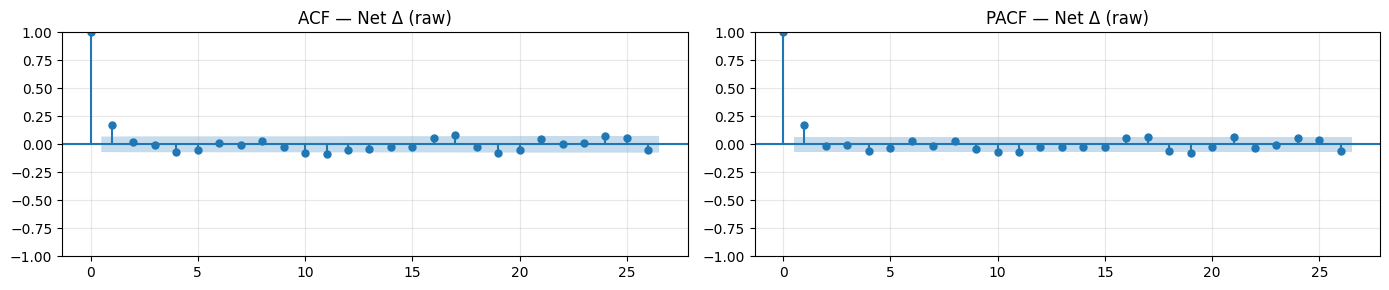

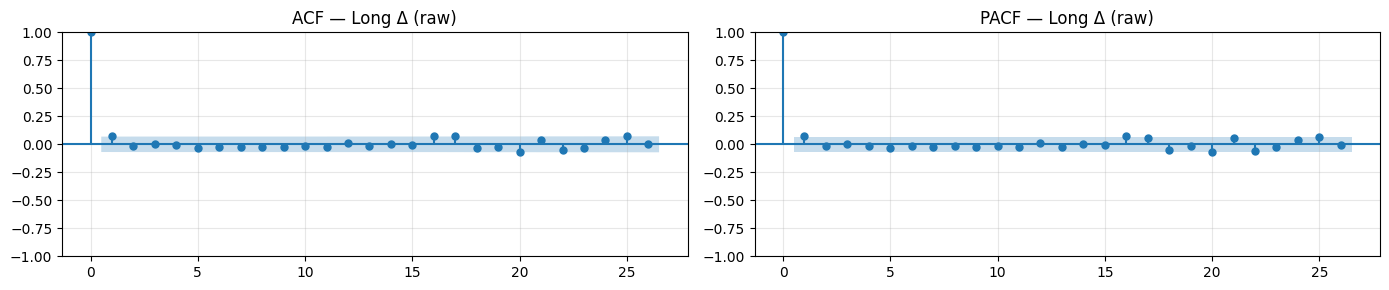

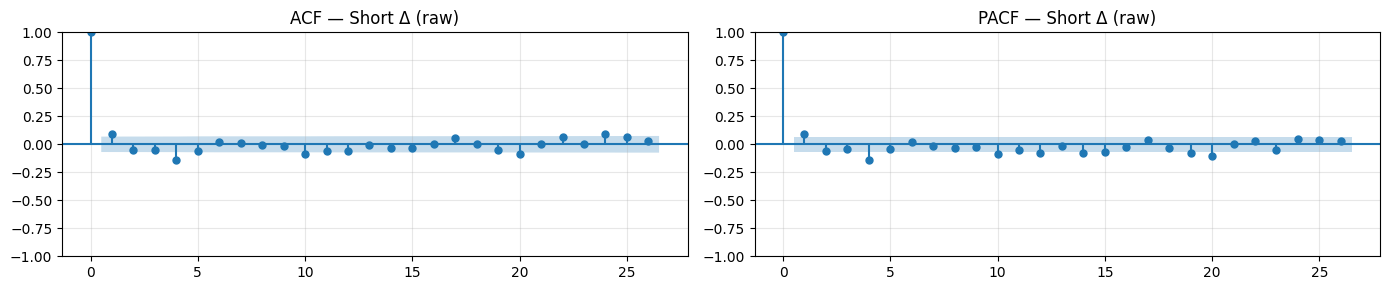

In [12]:
LAGS = 26  # ~6 months of weekly data

for col, label in zip(RAW_RESPONSES, ['Net Δ (raw)', 'Long Δ (raw)', 'Short Δ (raw)']):
    fig, axes = plt.subplots(1, 2, figsize=(14, 3))
    s = dataset[col].dropna()
    plot_acf(s, lags=LAGS, ax=axes[0], alpha=0.05)
    axes[0].set_title(f'ACF — {label}')
    plot_pacf(s, lags=LAGS, ax=axes[1], alpha=0.05, method='ywm')
    axes[1].set_title(f'PACF — {label}')
    plt.tight_layout()
    plt.show()

In [13]:
# Ljung-Box test for residual autocorrelation
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_results = []
for col, label in zip(ALL_RESPONSES, change_labels_short):
    s = dataset[col].dropna()
    lb = acorr_ljungbox(s, lags=[4, 8, 13], return_df=True)
    for lag, row in lb.iterrows():
        lb_results.append({
            'Series': label,
            'Lag': lag,
            'LB stat': round(row['lb_stat'], 3),
            'p-value': round(row['lb_pvalue'], 4),
            'Autocorrelated?': 'Yes' if row['lb_pvalue'] < 0.05 else 'No',
        })

pd.DataFrame(lb_results).pivot(index='Series', columns='Lag', values='p-value').round(4)

Lag,4,8,13
Series,,,
Long Δ (raw),0.3136,0.5246,0.8033
Long Δ/OI,0.0000,0.0000,0.0000
Net Δ (raw),0.0000,0.0002,0.0000
Net Δ/OI,0.0014,0.0044,0.0000
Short Δ (raw),0.0000,0.0001,0.0000
Short Δ/OI,0.0003,0.0007,0.0001


---
## 4. Cross-Correlation Between Responses

The joint structure of (Net, Long, Short) changes motivates the **multivariate** KF over three univariate models. We check:
- Contemporaneous correlation → shared observation noise
- Lead-lag structure → one response anticipates another

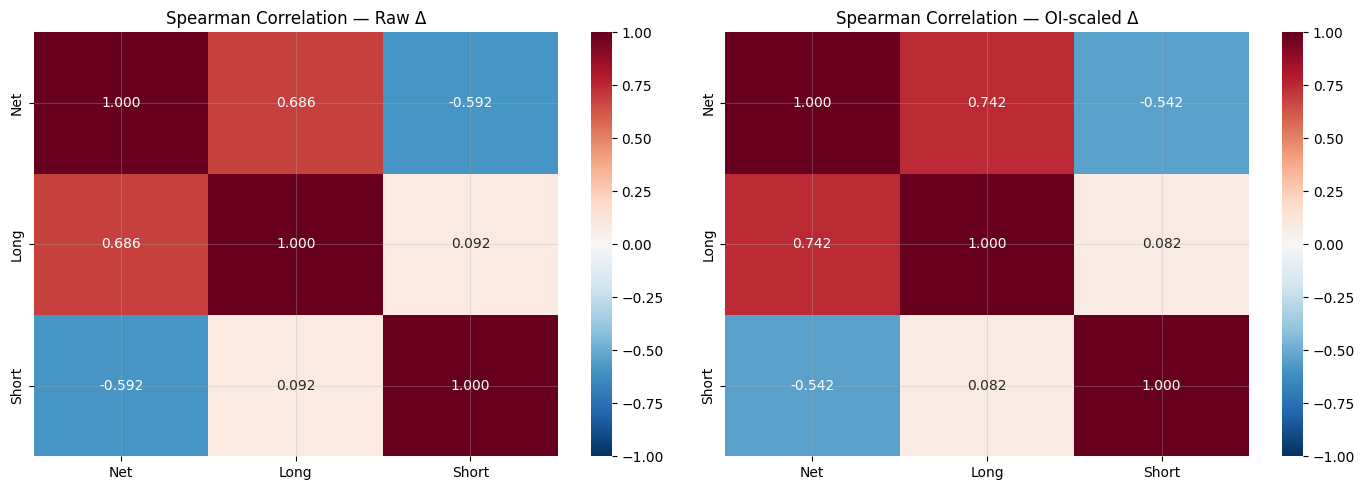

In [14]:
# Contemporaneous Spearman correlation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, responses, title in zip(
    axes,
    [RAW_RESPONSES, OI_RESPONSES],
    ['Raw Δ', 'OI-scaled Δ'],
):
    sub = dataset[responses].dropna()
    corr = sub.corr(method='spearman')
    labels = ['Net', 'Long', 'Short']
    sns.heatmap(
        corr, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
        vmin=-1, vmax=1, ax=ax,
        xticklabels=labels, yticklabels=labels,
    )
    ax.set_title(f'Spearman Correlation — {title}')

plt.tight_layout()
plt.show()

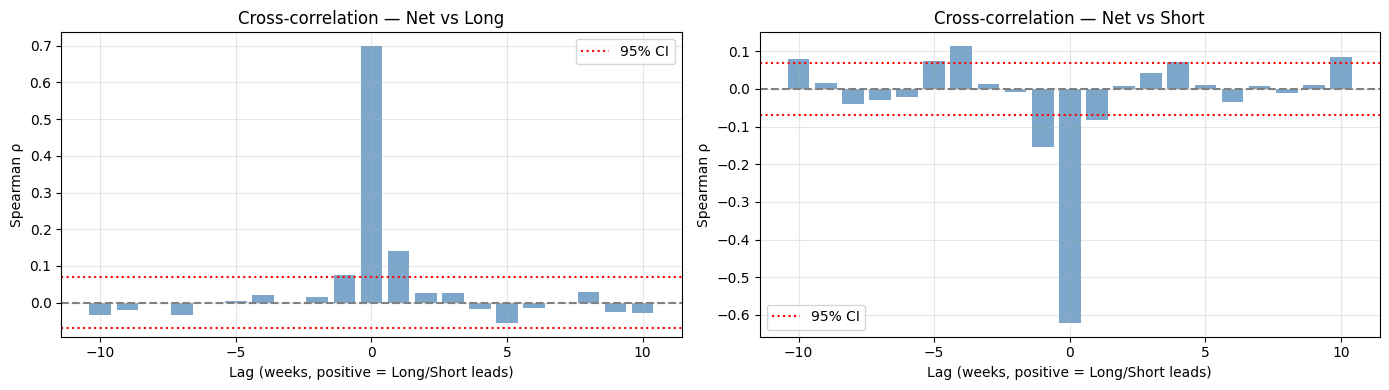

In [15]:
# Lead-lag cross-correlations (Net vs Long, Net vs Short)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
pairs = [
    ('prior_report_ManagedMoney_NetPosition_change',
     'prior_report_ManagedMoney_LongPosition_change',
     'Net vs Long'),
    ('prior_report_ManagedMoney_NetPosition_change',
     'prior_report_ManagedMoney_ShortPosition_change',
     'Net vs Short'),
]

for ax, (col_a, col_b, label) in zip(axes, pairs):
    sub = dataset[[col_a, col_b]].dropna()
    lags = range(-10, 11)
    xcorr = [sub[col_a].corr(sub[col_b].shift(lag)) for lag in lags]
    ax.bar(lags, xcorr, color='steelblue', alpha=0.7)
    ax.axhline(0, color='grey', linestyle='--')
    ax.axhline(1.96 / np.sqrt(len(sub)), color='red', linestyle=':', label='95% CI')
    ax.axhline(-1.96 / np.sqrt(len(sub)), color='red', linestyle=':')
    ax.set_title(f'Cross-correlation — {label}')
    ax.set_xlabel('Lag (weeks, positive = Long/Short leads)')
    ax.set_ylabel('Spearman ρ')
    ax.legend()

plt.tight_layout()
plt.show()

---
## 5. Feature Pre-selection

We compute Spearman correlations between all 20 candidate features and the 6 responses, then select a compact subset (~5) that:
1. Shows meaningful signal (|ρ| > threshold) for at least one response
2. Spans different information categories (price, OI, vol, spread, volume)
3. Has low inter-feature correlation (avoids redundancy)

In [16]:
# Load feature definitions
import json, pathlib

FEATURE_DEF_PATH = pathlib.Path('../../../cache/output/wti/mm/feature_definitions.json')
with open(FEATURE_DEF_PATH) as f:
    feat_defs = json.load(f)

feature_names = [f['name'] for f in feat_defs['features']]
feature_categories = {f['name']: f['category'] for f in feat_defs['features']}

print(f'{len(feature_names)} features across categories:')
pd.Series([f['category'] for f in feat_defs['features']]).value_counts()

20 features across categories:


open_interest         4
cot_position          3
cot_position_to_oi    3
volume                3
volatility            3
price                 3
spread                1
Name: count, dtype: int64

In [17]:
# Spearman correlations: features × responses
available_features = [f for f in feature_names if f in dataset.columns]
print(f'Features available in dataset: {len(available_features)} / {len(feature_names)}')

corr_rows = []
for feat in available_features:
    row = {'feature': feat, 'category': feature_categories.get(feat, '?')}
    for resp in ALL_RESPONSES:
        sub = dataset[[feat, resp]].dropna()
        if len(sub) > 20:
            rho, _ = stats.spearmanr(sub[feat], sub[resp])
        else:
            rho = np.nan
        short_resp = resp.replace('prior_report_ManagedMoney_', 'MM_').replace('_change', 'Δ').replace('_to_openinterest', '/OI')
        row[short_resp] = round(rho, 4)
    corr_rows.append(row)

corr_df = pd.DataFrame(corr_rows).set_index('feature')

# Max absolute correlation across all responses (signal strength)
resp_cols = [c for c in corr_df.columns if c != 'category']
corr_df['max_abs_rho'] = corr_df[resp_cols].abs().max(axis=1)
corr_df.sort_values('max_abs_rho', ascending=False)

Features available in dataset: 20 / 20


TypeError: type numpy.ndarray doesn't define __round__ method

In [18]:
short_resp

'MM_NetPositionΔ'

In [20]:
rho

array([[1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.]])

In [19]:
round(rho, 4)

TypeError: type numpy.ndarray doesn't define __round__ method

In [ ]:
# Heatmap: features × responses (sorted by signal strength)
top_n = 20
plot_df = corr_df.sort_values('max_abs_rho', ascending=False).head(top_n)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    plot_df[resp_cols].astype(float),
    annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    vmin=-0.6, vmax=0.6, ax=ax,
    linewidths=0.4,
)
ax.set_title('Spearman ρ: Features × MM Responses (top 20 by max |ρ|)')
ax.set_ylabel('Feature')
ax.set_xlabel('Response')
plt.tight_layout()
plt.show()

In [ ]:
# Inter-feature correlation for candidate features
# Proposed subset (one per category, high signal)
CANDIDATE_FEATURES = [
    'F1_RolledPrice_change',                               # Price
    'F1_RolledPrice_rolling_20D_volatility',               # Volatility
    'prior_5D_AGG_OI_change',                              # Open interest
    'prior_report_SyntheticF1MinusF2_RolledPrice_change',  # Spread / curve
    'prior_cumulative_5D_F1_Volume_change',                # Volume
]

avail_candidates = [f for f in CANDIDATE_FEATURES if f in dataset.columns]
print('Candidate features found:', len(avail_candidates))

# Show their signal strength
corr_df.loc[avail_candidates, resp_cols + ['category', 'max_abs_rho']]

In [ ]:
# Inter-feature Spearman correlation (check for redundancy)
feat_corr = dataset[avail_candidates].corr(method='spearman')

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    feat_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    vmin=-1, vmax=1, ax=ax,
    xticklabels=[f.split('_')[0] + '...' for f in avail_candidates],
    yticklabels=[f.split('_')[0] + '...' for f in avail_candidates],
)
ax.set_title('Inter-feature Spearman Correlation (candidate subset)')
plt.tight_layout()
plt.show()

In [ ]:
# Time series plots of selected features
fig, axes = plt.subplots(len(avail_candidates), 1, figsize=(14, 3 * len(avail_candidates)), sharex=True)

for ax, feat in zip(axes, avail_candidates):
    s = dataset[feat].dropna()
    ax.plot(dataset.loc[s.index, 'tradeDate'], s, linewidth=0.8, color='steelblue')
    ax.set_ylabel(feat.split('_')[0], fontsize=9)
    ax.set_title(feat, fontsize=9)

axes[-1].set_xlabel('Date')
plt.suptitle('Selected Feature Candidates — Time Series', y=1.01, fontsize=11)
plt.tight_layout()
plt.show()

---
## 6. Summary & Design Decisions

### State Space Setup for Notebook 02

| Component | Choice | Rationale |
|---|---|---|
| **Observation vector** `y_t` | [Net Δ, Long Δ, Short Δ] (raw, 3×1) | Stationary; clean multivariate structure |
| **State model** (baseline) | Local level (random walk) | Simplest; levels already non-stationary |
| **Exogenous features** | 5 candidates below | One per info category, low inter-correlation |
| **Library** | `statsmodels.tsa.statespace.MLEModel` | MLE estimation, smoother included |

### Selected Features for Notebooks 03+

| # | Feature | Category |
|---|---|---|
| 1 | `F1_RolledPrice_change` | Price |
| 2 | `F1_RolledPrice_rolling_20D_volatility` | Volatility |
| 3 | `prior_5D_AGG_OI_change` | Open Interest |
| 4 | `prior_report_SyntheticF1MinusF2_RolledPrice_change` | Spread / Curve |
| 5 | `prior_cumulative_5D_F1_Volume_change` | Volume |

In [ ]:
# Save selected features and responses for downstream notebooks
SELECTED_FEATURES = [
    'F1_RolledPrice_change',
    'F1_RolledPrice_rolling_20D_volatility',
    'prior_5D_AGG_OI_change',
    'prior_report_SyntheticF1MinusF2_RolledPrice_change',
    'prior_cumulative_5D_F1_Volume_change',
]

SELECTED_RESPONSES_RAW = [
    'prior_report_ManagedMoney_NetPosition_change',
    'prior_report_ManagedMoney_LongPosition_change',
    'prior_report_ManagedMoney_ShortPosition_change',
]

SELECTED_RESPONSES_OI = [
    'prior_report_ManagedMoney_NetPosition_to_openinterest_change',
    'prior_report_ManagedMoney_LongPosition_to_openinterest_change',
    'prior_report_ManagedMoney_ShortPosition_to_openinterest_change',
]

config = {
    'selected_features': SELECTED_FEATURES,
    'responses_raw': SELECTED_RESPONSES_RAW,
    'responses_oi': SELECTED_RESPONSES_OI,
}

out_path = pathlib.Path('../../../cache/output/wti/mm/kf_config.json')
out_path.parent.mkdir(parents=True, exist_ok=True)
with open(out_path, 'w') as f:
    json.dump(config, f, indent=2)

print(f'Config saved to {out_path}')
print(json.dumps(config, indent=2))